there are two libraries to read data from data base

In [ ]:
# %pip  install pyodbc sqlalchemy
%pip install --upgrade pip

In [2]:
from  sqlalchemy import create_engine
import pandas as pd
# sqlalchemy is a big libaray we are importing just a create_engine tool to connect with data base
'''
mssql+pyodbc is a mircrosft sql server and pyodbc is a driver for connection
Server&trusted_connection=yes is windows authentications
ODBC+Driver it is a translator or driver between python and DB

'''
engine  = create_engine('mssql+pyodbc://localhost\SQLEXPRESS01/MyDatabase?driver=ODBC+Driver+18+for+SQL+Server&trusted_connection=yes&TrustServerCertificate=yes&Encrypt=no')

qury= 'SELECT * FROM customers'
new_data=pd.read_sql_query(qury,con=engine)


In [9]:
new_data


,id,first_name,country,score
0,1,Maria,Germany,350
1,2,John,USA,900
2,3,Georg,UK,750
3,4,Martin,Germany,500
4,5,Peter,USA,0


In [10]:
type(new_data)

pandas.DataFrame

In [14]:
new_data[['country','score']]

,country,score
0,Germany,350
1,USA,900
2,UK,750
3,Germany,500
4,USA,0


In [17]:
# check group
new_data.groupby(by='country')['score'].mean()


country
Germany    425.0
UK         750.0
USA        450.0
Name: score, dtype: float64

In [3]:
new_data.groupby(by='country')['score'].max()

country
Germany    500
UK         750
USA        900
Name: score, dtype: int64

<Axes: title={'center': 'result'}, xlabel='country', ylabel='score'>

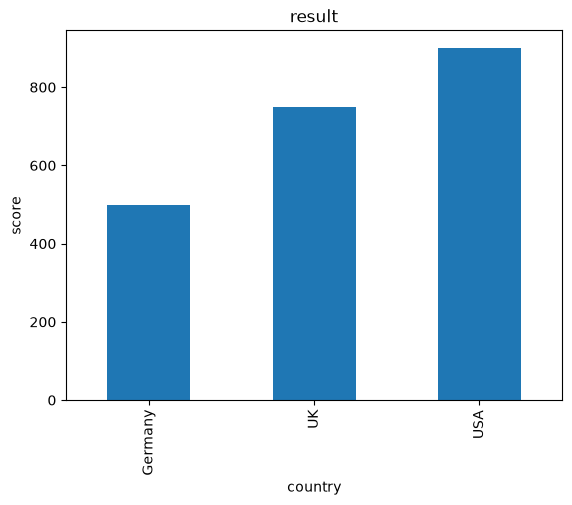

In [ ]:
import matplotlib.pyplot
new_data.groupby(by='country')['score'].max().plot(kind='bar',title='result',ylabel='score',xlabel='country')

In [4]:
new_data.groupby(['country']).max()

,id,first_name,score
country,,,
Germany,4,Martin,500
UK,3,Georg,750
USA,5,Peter,900
